In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup and Load Data

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_pickle("../../data/processed/data_processed.pkl")
os.makedirs("../../reports/figures/", exist_ok=True)

LABEL_NAME = {
    0: "dws",
    1: "ups",
    2: "wlk",
    3: "jog",
    4: "sit",
    5: "std"
}


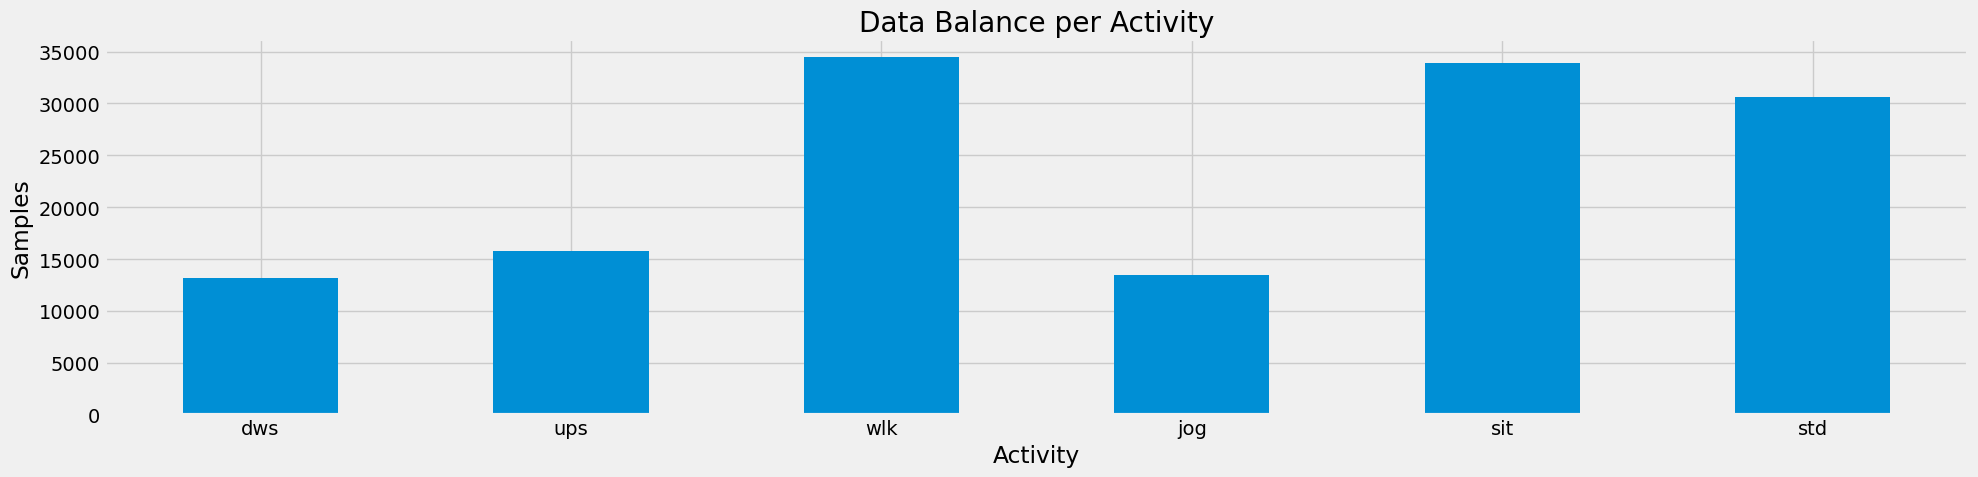

In [2]:

# 2. Data Balance (a)

balance = df["label"].value_counts().sort_index()

plt.figure()
balance.plot(kind="bar")
plt.xticks(balance.index, [LABEL_NAME[l] for l in balance.index])
plt.title("Data Balance per Activity")
plt.xlabel("Activity")
plt.xticks(rotation=0)
plt.ylabel("Samples")
plt.tight_layout()
plt.show()



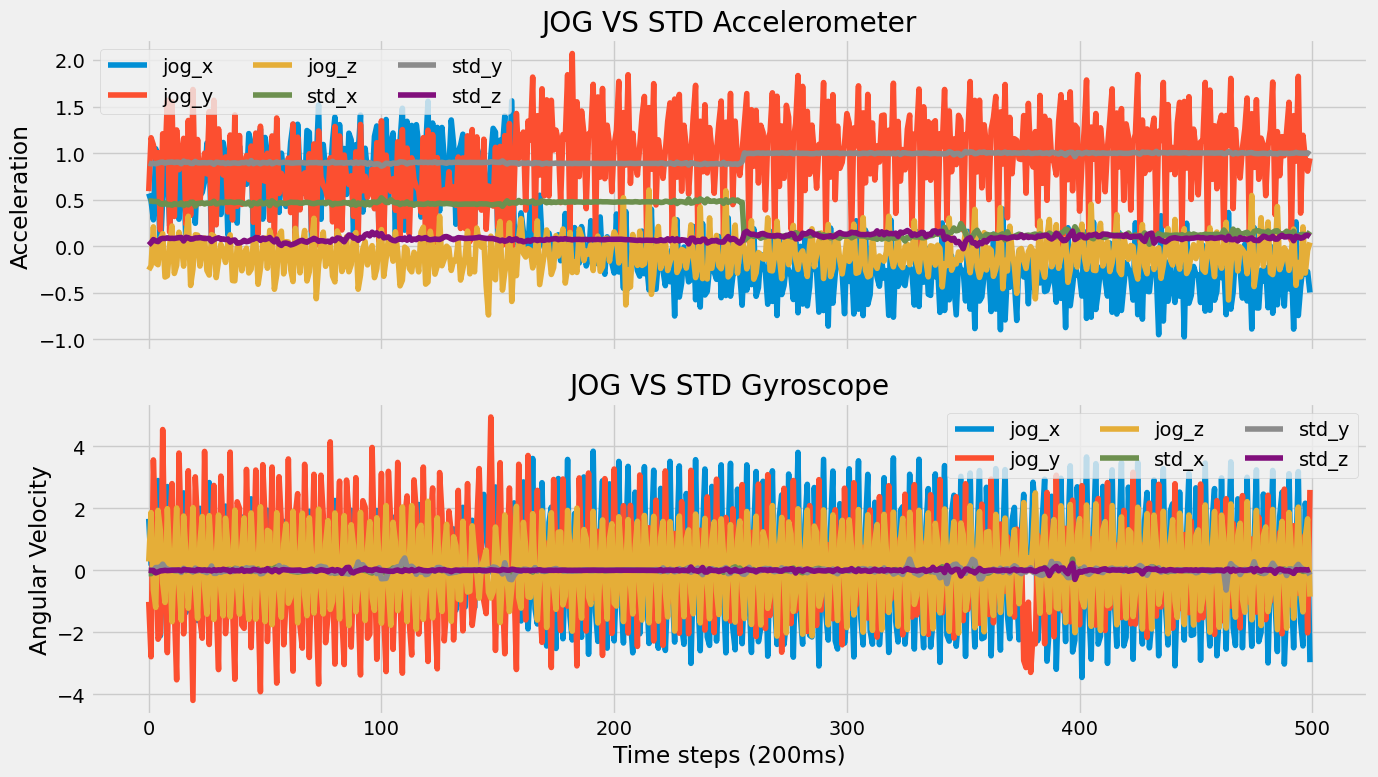

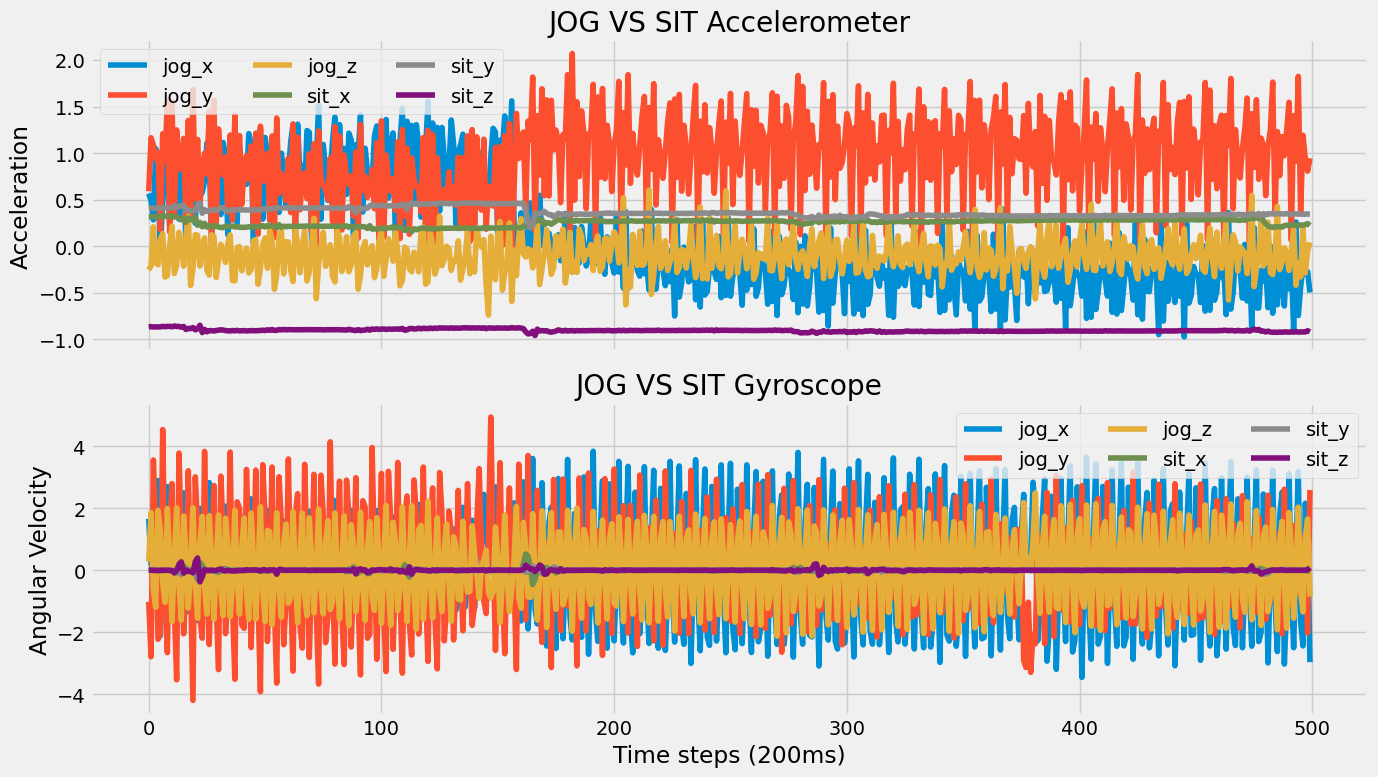

In [3]:

# 3. Compare multiple activities on the same plot (b)

def plot_signals(
    df,
    labels,
    acc_cols=["acc_x", "acc_y", "acc_z"],
    gyr_cols=["gyr_x", "gyr_y", "gyr_z"],
    n_samples=500,
    title=""
):
    fig, axes = plt.subplots(nrows=2, figsize=(14, 8), sharex=True)

    user = df[df["label"].isin(labels)]["user_id"].iloc[0]

    for label in labels:
        subset = (
            df[(df["label"] == label) & (df["user_id"] == user)]
            .head(n_samples)
            .reset_index(drop=True)
        )
        for col in acc_cols:
            axes[0].plot(subset[col], label=f"{LABEL_NAME[label]}_{col[-1]}")

    axes[0].set_title(f"{title} Accelerometer")
    axes[0].set_ylabel("Acceleration")
    axes[0].legend(ncol=3)

    for label in labels:
        subset = (
            df[(df["label"] == label) & (df["user_id"] == user)]
            .head(n_samples)
            .reset_index(drop=True)
        )
        for col in gyr_cols:
            axes[1].plot(subset[col], label=f"{LABEL_NAME[label]}_{col[-1]}")

    axes[1].set_title(f"{title} Gyroscope")
    axes[1].set_xlabel("Time steps (200ms)")
    axes[1].set_ylabel("Angular Velocity")
    axes[1].legend(ncol=3)

    plt.tight_layout()
    plt.show()

plot_signals(df, [3, 5], title="JOG VS STD")
plot_signals(df, [3, 4], title="JOG VS SIT")


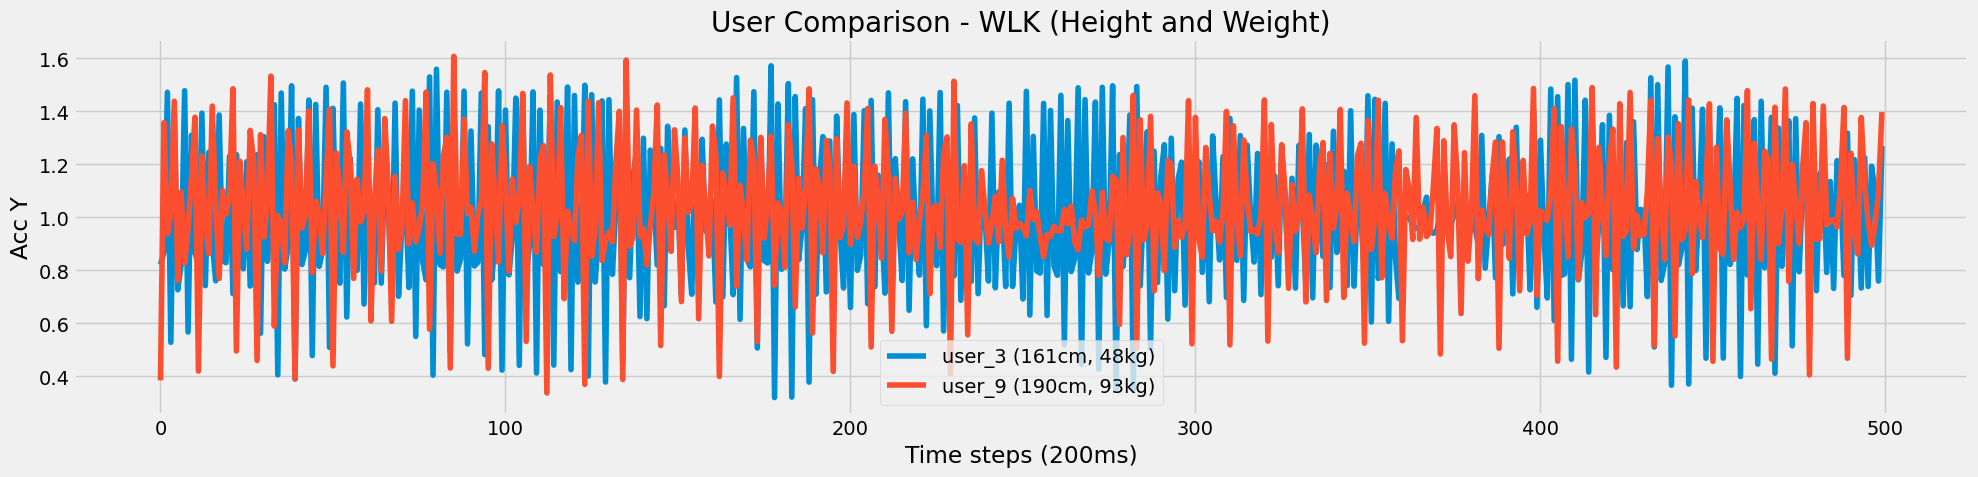

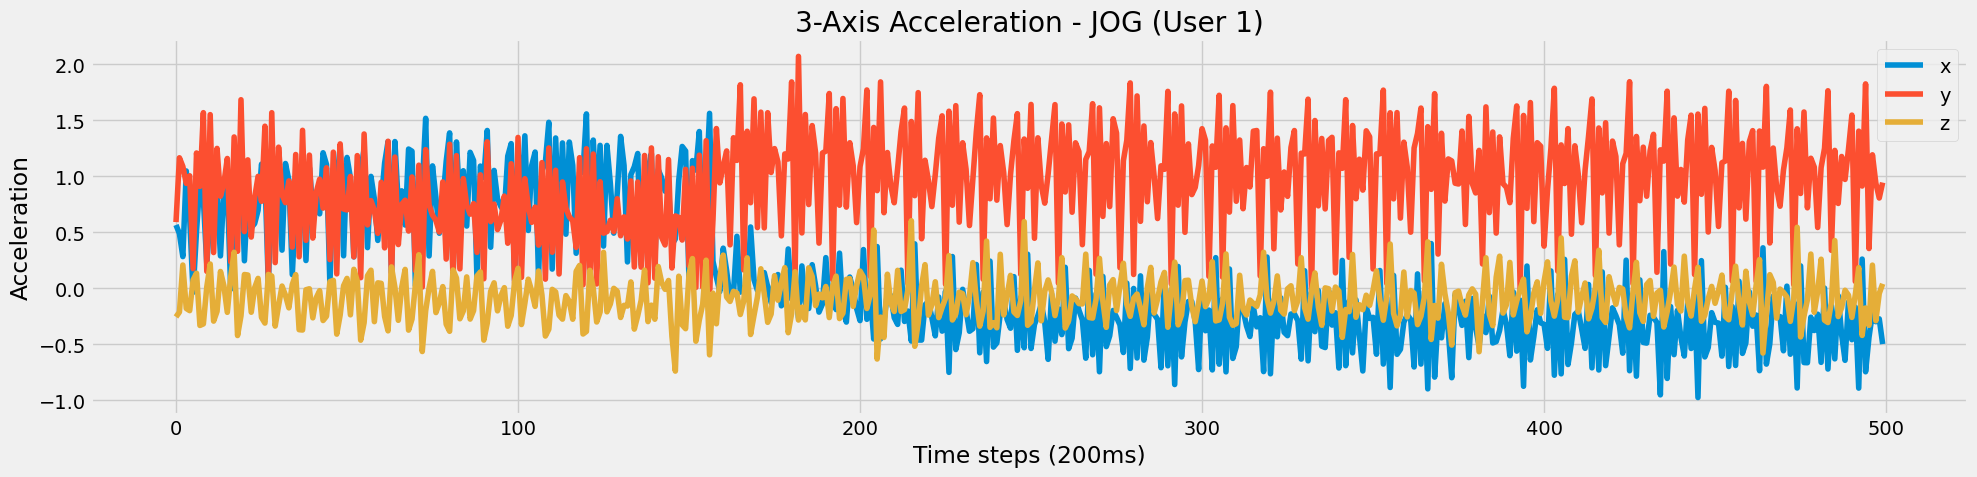

In [4]:

# 4. Compare multiple participants in an activity (c)

label = 2

user_info = (
    df[df["label"] == label]
    .groupby("user_id")[["height", "weight"]]
    .first()
    .sort_values("height")
)

short_user = user_info.iloc[0]
tall_user = user_info.iloc[-1]

plt.figure()

for u, info in zip(
    [short_user.name, tall_user.name],
    [short_user, tall_user]
):
    u_df = (
        df[(df["label"] == label) & (df["user_id"] == u)]
        .head(500)
        .reset_index(drop=True)
    )

    plt.plot(
        u_df["acc_y"],
        label=f"user_{u} ({info.height}cm, {info.weight}kg)"
    )

plt.title("User Comparison - WLK (Height and Weight)")
plt.xlabel("Time steps (200ms)")
plt.ylabel("Acc Y")
plt.legend()
plt.tight_layout()
plt.show()

label = 3
user = df[df["label"] == label]["user_id"].iloc[0]

multi_axis_df = (
    df[(df["label"] == label) & (df["user_id"] == user)]
    .head(500)
    .reset_index(drop=True)
)

plt.figure()
plt.plot(multi_axis_df["acc_x"], label="x")
plt.plot(multi_axis_df["acc_y"], label="y")
plt.plot(multi_axis_df["acc_z"], label="z")
plt.title(f"3-Axis Acceleration - {LABEL_NAME[label].upper()} (User {user})")
plt.xlabel("Time steps (200ms)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()


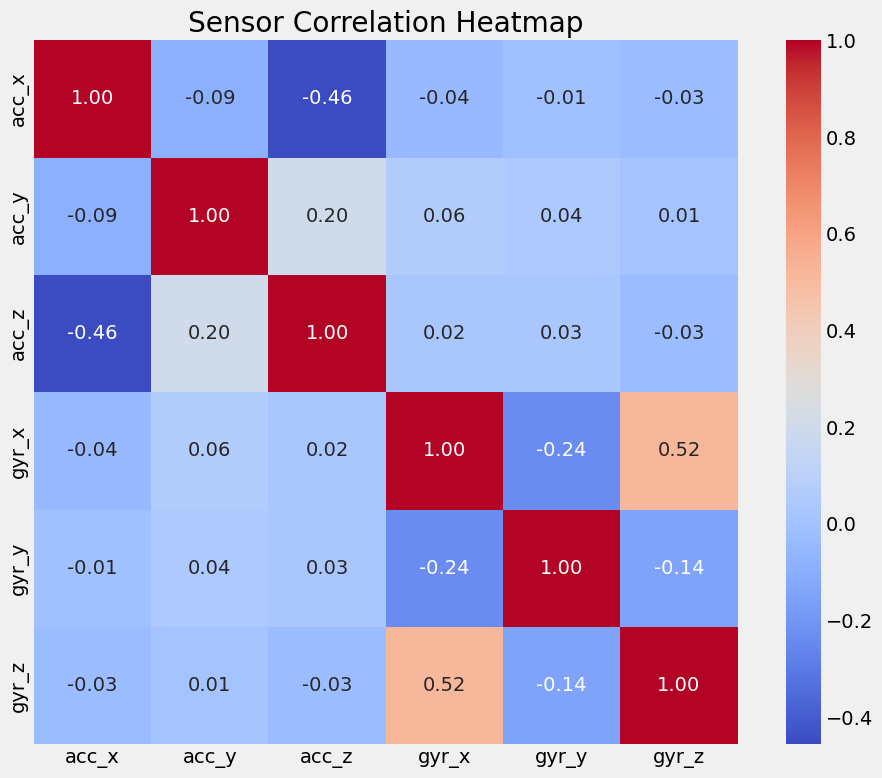

In [5]:

# 5. Correlation

corr_df = df[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.show()


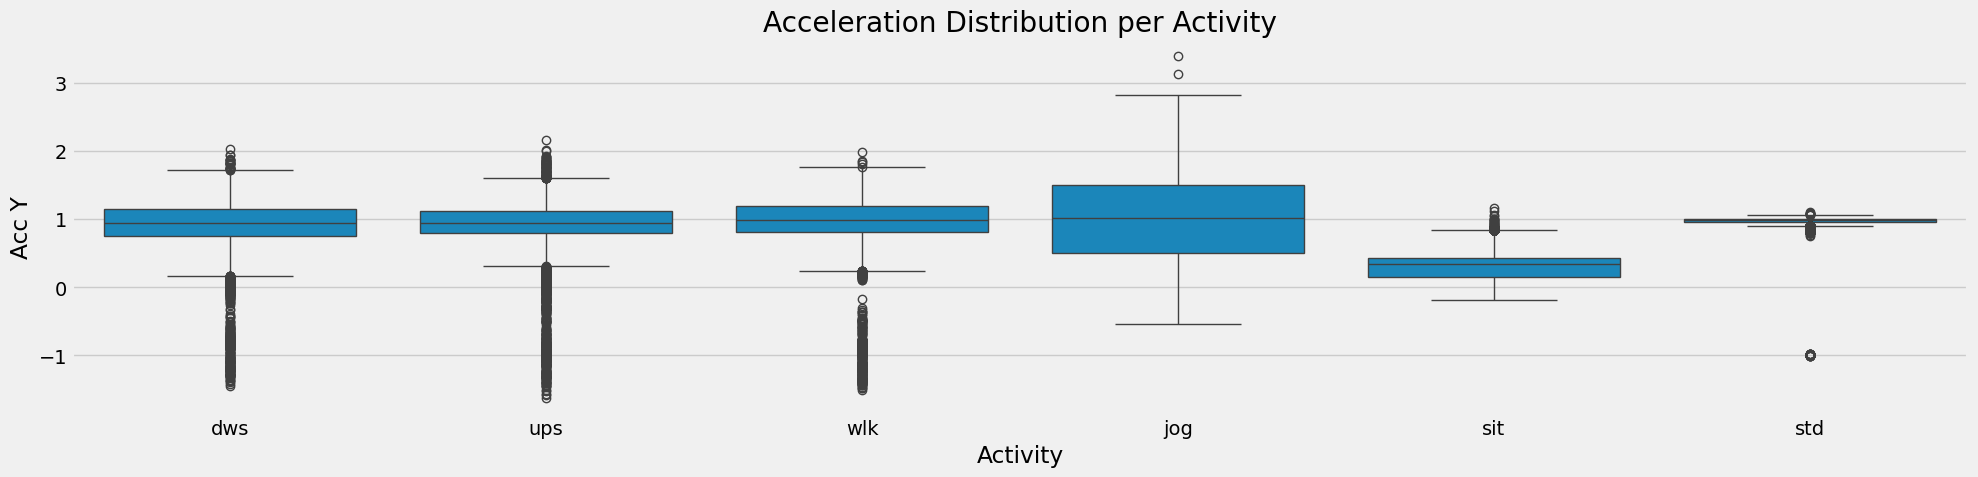

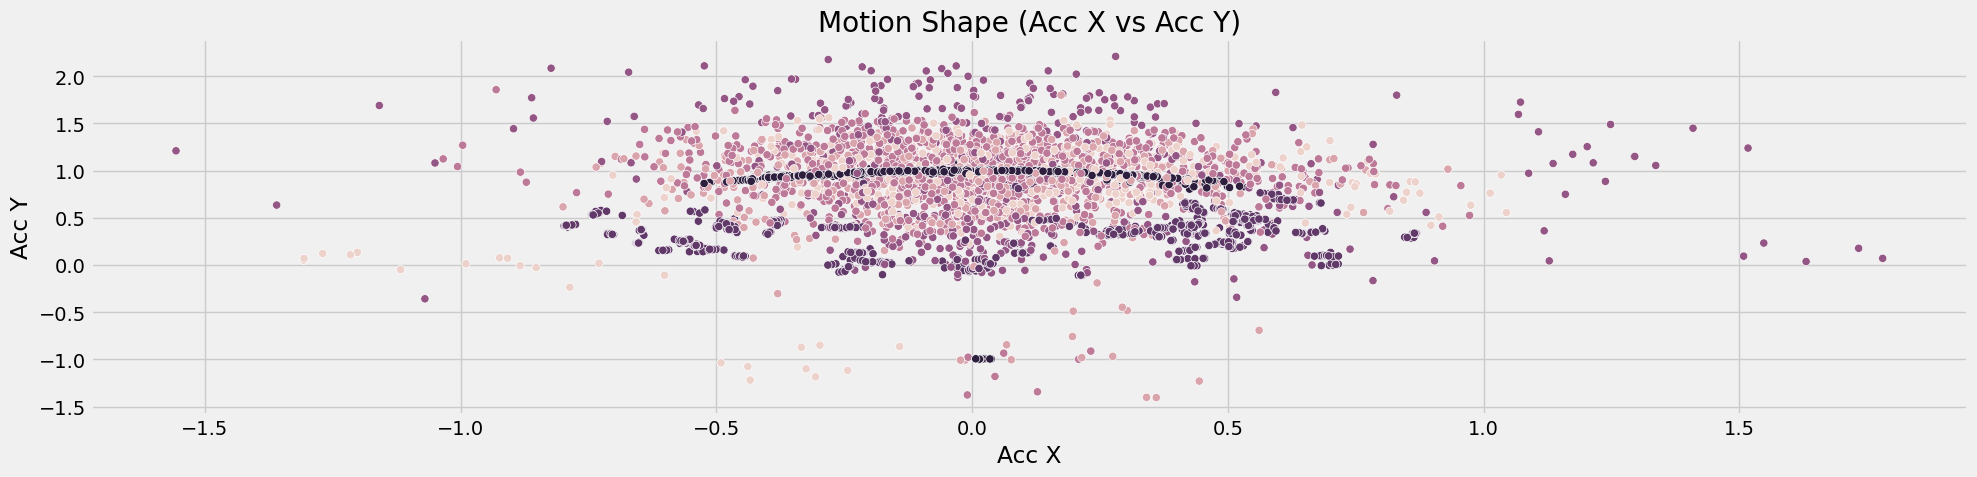

In [6]:
# 6. Checklist

plt.figure()
sns.boxplot(x="label", y="acc_y", data=df)
plt.xticks(df["label"].unique(), [LABEL_NAME[l] for l in df["label"].unique()])
plt.title("Acceleration Distribution per Activity")
plt.xlabel("Activity")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.show()

scatter_df = df.sample(5000, random_state=42)

plt.figure()
sns.scatterplot(
    x="acc_x",
    y="acc_y",
    hue="label",
    data=scatter_df,
    legend=False
)
plt.title("Motion Shape (Acc X vs Acc Y)")
plt.xlabel("Acc X")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.show()